# Physics-Based Soil-Water Model

The aim of this notebook is to build a simple physical representation of how soil moisture changes over time.

Water enters the soil mainly through rainfall and irrigation. Water is lost through processes such as evapotranspiration and drainage. The model will use these processes to estimate the change in soil moisture between consecutive observations.

The basic water-balance idea is:

ΔS = P + I - ET - D

where:

- S represents water stored in the soil
- P represents rainfall
- I represents irrigation
- ET represents evapotranspiration
- D represents drainage

The model will be kept simple at first. Parameters that are not directly available from the field dataset will not be assumed without justification. Where necessary, effective parameters will be estimated from the observed data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

data_file = Path("../data/processed/irrigation_model_data.csv")

model_data = pd.read_csv(
    data_file,
    parse_dates=["Timestamps"]
)

print("Rows:", len(model_data))
print("Columns:", len(model_data.columns))
print("Start:", model_data["Timestamps"].min())
print("End:", model_data["Timestamps"].max())

model_data.head()

Rows: 11770
Columns: 10
Start: 2022-08-01 00:15:00
End: 2023-02-28 23:45:00


,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6,Rainfall,Irrigation,Temperature
0,2022-08-01 00:15:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,27.0
1,2022-08-01 00:30:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.9
2,2022-08-01 00:45:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
3,2022-08-01 01:00:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
4,2022-08-01 01:15:00,0.257,0.133,0.172,0.204,0.2,0.155,0.0,0.0,26.8


In [2]:
physics_data = model_data.copy()

physics_data["Delta_theta"] = physics_data["Port1"].diff()
physics_data["Delta_time"] = physics_data["Timestamps"].diff()

physics_data[
    ["Timestamps", "Port1", "Delta_theta", "Delta_time"]
].head(10)

,Timestamps,Port1,Delta_theta,Delta_time
0,2022-08-01 00:15:00,0.257,NaN,NaT
1,2022-08-01 00:30:00,0.257,0.000,0 days 00:15:00
2,2022-08-01 00:45:00,0.257,0.000,0 days 00:15:00
3,2022-08-01 01:00:00,0.257,0.000,0 days 00:15:00
4,2022-08-01 01:15:00,0.257,0.000,0 days 00:15:00
5,2022-08-01 01:30:00,0.256,-0.001,0 days 00:15:00
6,2022-08-01 01:45:00,0.256,0.000,0 days 00:15:00
7,2022-08-01 02:00:00,0.256,0.000,0 days 00:15:00
8,2022-08-01 02:15:00,0.255,-0.001,0 days 00:15:00
9,2022-08-01 02:30:00,0.255,0.000,0 days 00:15:00


In [3]:
physics_15min = physics_data[
    physics_data["Delta_time"] == pd.Timedelta(minutes=15)
].copy()

print("Original rows:", len(physics_data))
print("Valid 15-minute transitions:", len(physics_15min))
print("Removed because of gaps:", len(physics_data) - len(physics_15min))

Original rows: 11770
Valid 15-minute transitions: 11626
Removed because of gaps: 144


In [4]:
water_input = physics_15min[
    (physics_15min["Rainfall"] > 0) |
    (physics_15min["Irrigation"] > 0)
]

no_water_input = physics_15min[
    (physics_15min["Rainfall"] == 0) &
    (physics_15min["Irrigation"] == 0)
]

print("Intervals with water input:", len(water_input))
print("Intervals without water input:", len(no_water_input))

print(
    "Mean moisture change with water:",
    water_input["Delta_theta"].mean()
)

print(
    "Mean moisture change without water:",
    no_water_input["Delta_theta"].mean()
)

Intervals with water input: 916
Intervals without water input: 10129
Mean moisture change with water: 0.00047270742358078584
Mean moisture change without water: -4.1366373778260435e-05


In [5]:
rain_only = physics_15min[
    (physics_15min["Rainfall"] > 0) &
    (physics_15min["Irrigation"] == 0)
]

irrigation_only = physics_15min[
    (physics_15min["Rainfall"] == 0) &
    (physics_15min["Irrigation"] > 0)
]

both = physics_15min[
    (physics_15min["Rainfall"] > 0) &
    (physics_15min["Irrigation"] > 0)
]

print("Rain only intervals:", len(rain_only))
print("Mean change:", rain_only["Delta_theta"].mean())

print("\nIrrigation only intervals:", len(irrigation_only))
print("Mean change:", irrigation_only["Delta_theta"].mean())

print("\nRain + irrigation intervals:", len(both))
print("Mean change:", both["Delta_theta"].mean())

Rain only intervals: 90
Mean change: 0.0020111111111111115

Irrigation only intervals: 816
Mean change: 0.0003088235294117645

Rain + irrigation intervals: 10
Mean change: 0.0


In [6]:
balance_data = physics_15min[
    physics_15min["Irrigation"].notna()
].copy()

print("15-minute transitions:", len(physics_15min))
print("Usable transitions:", len(balance_data))
print("Removed for missing irrigation:", len(physics_15min) - len(balance_data))

15-minute transitions: 11626
Usable transitions: 11045
Removed for missing irrigation: 581


In [7]:
from sklearn.linear_model import LinearRegression

X = balance_data[["Rainfall", "Irrigation"]]
y = balance_data["Delta_theta"]

water_balance_model = LinearRegression()
water_balance_model.fit(X, y)

print("Intercept:", water_balance_model.intercept_)
print("Rainfall coefficient:", water_balance_model.coef_[0])
print("Irrigation coefficient:", water_balance_model.coef_[1])

Intercept: -2.6465443768046576e-05
Rainfall coefficient: 0.0002841229083883118
Irrigation coefficient: 0.0004048182809186213


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

balance_data["Delta_theta_pred"] = water_balance_model.predict(
    balance_data[["Rainfall", "Irrigation"]]
)

mae = mean_absolute_error(
    balance_data["Delta_theta"],
    balance_data["Delta_theta_pred"]
)

rmse = np.sqrt(
    mean_squared_error(
        balance_data["Delta_theta"],
        balance_data["Delta_theta_pred"]
    )
)

r2 = r2_score(
    balance_data["Delta_theta"],
    balance_data["Delta_theta_pred"]
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.00022382803801602983
RMSE: 0.0012013564503066659
R²: 0.011730028239989254


In [9]:
drying_data = balance_data[
    (balance_data["Rainfall"] == 0) &
    (balance_data["Irrigation"] == 0)
].copy()

drying_data["Moisture_group"] = pd.qcut(
    drying_data["Port1"],
    q=5,
    duplicates="drop"
)

moisture_behavior = (
    drying_data
    .groupby("Moisture_group", observed=True)["Delta_theta"]
    .agg(["count", "mean", "std"])
)

moisture_behavior

,count,mean,std
Moisture_group,,,
"(0.158, 0.182]",2123,-0.000016,0.000346
"(0.182, 0.221]",1957,-0.000069,0.000363
"(0.221, 0.244]",2227,-0.000032,0.000449
"(0.244, 0.253]",1812,-0.000023,0.000367
"(0.253, 0.339]",2010,-0.000068,0.000671


In [10]:
temp_behavior = drying_data.copy()

temp_behavior["Temperature_group"] = pd.qcut(
    temp_behavior["Temperature"],
    q=5,
    duplicates="drop"
)

temperature_summary = (
    temp_behavior
    .groupby("Temperature_group", observed=True)["Delta_theta"]
    .agg(["count", "mean", "std"])
)

temperature_summary

,count,mean,std
Temperature_group,,,
"(7.699, 17.7]",2059,-0.000002,0.000554
"(17.7, 20.7]",2002,-0.000021,0.000296
"(20.7, 23.8]",2060,-0.000036,0.000332
"(23.8, 26.9]",1987,-0.000060,0.000385
"(26.9, 37.9]",2021,-0.000089,0.000621


In [11]:
X_temp = balance_data[
    ["Rainfall", "Irrigation", "Temperature"]
]

y_temp = balance_data["Delta_theta"]

water_balance_temp_model = LinearRegression()
water_balance_temp_model.fit(X_temp, y_temp)

balance_data["Delta_theta_temp_pred"] = (
    water_balance_temp_model.predict(X_temp)
)

mae_temp = mean_absolute_error(
    y_temp,
    balance_data["Delta_theta_temp_pred"]
)

rmse_temp = np.sqrt(
    mean_squared_error(
        y_temp,
        balance_data["Delta_theta_temp_pred"]
    )
)

r2_temp = r2_score(
    y_temp,
    balance_data["Delta_theta_temp_pred"]
)

print("Intercept:", water_balance_temp_model.intercept_)
print("Rainfall coefficient:", water_balance_temp_model.coef_[0])
print("Irrigation coefficient:", water_balance_temp_model.coef_[1])
print("Temperature coefficient:", water_balance_temp_model.coef_[2])

print("\nMAE:", mae_temp)
print("RMSE:", rmse_temp)
print("R²:", r2_temp)

Intercept: 0.0001437362609921632
Rainfall coefficient: 0.00027797912942608257
Irrigation coefficient: 0.00043702141037678307
Temperature coefficient: -7.6093452446044795e-06

MAE: 0.0002305970945504503
RMSE: 0.0012007243707767082
R²: 0.012769687849662148


In [12]:
balance_data = balance_data.sort_values("Timestamps").copy()

split_index = int(len(balance_data) * 0.80)

train_data = balance_data.iloc[:split_index].copy()
test_data = balance_data.iloc[split_index:].copy()

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

print("\nTraining period:")
print(train_data["Timestamps"].min(), "to", train_data["Timestamps"].max())

print("\nTesting period:")
print(test_data["Timestamps"].min(), "to", test_data["Timestamps"].max())

Training observations: 8836
Testing observations: 2209

Training period:
2022-08-01 00:30:00 to 2022-11-01 00:30:00

Testing period:
2022-11-01 00:45:00 to 2023-02-28 23:45:00


In [13]:
X_train = train_data[
    ["Rainfall", "Irrigation", "Temperature"]
]

y_train = train_data["Delta_theta"]

X_test = test_data[
    ["Rainfall", "Irrigation", "Temperature"]
]

y_test = test_data["Delta_theta"]


physics_model = LinearRegression()
physics_model.fit(X_train, y_train)

test_predictions = physics_model.predict(X_test)


test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test,
    test_predictions
)


print("TRAINED COEFFICIENTS")
print("Intercept:", physics_model.intercept_)
print("Rainfall:", physics_model.coef_[0])
print("Irrigation:", physics_model.coef_[1])
print("Temperature:", physics_model.coef_[2])

print("\nTEST PERFORMANCE")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("R²:", test_r2)

TRAINED COEFFICIENTS
Intercept: 0.0001684108254741218
Rainfall: 0.00027767636413351477
Irrigation: 0.00044571758092297426
Temperature: -8.580618430283867e-06

TEST PERFORMANCE
MAE: 0.0001482555878885406
RMSE: 0.0005790997303324202
R²: -0.0007612151704394776


In [14]:
features_state = [
    "Port1",
    "Rainfall",
    "Irrigation",
    "Temperature"
]

X_train_state = train_data[features_state]
X_test_state = test_data[features_state]

state_model = LinearRegression()
state_model.fit(X_train_state, y_train)

state_predictions = state_model.predict(X_test_state)

state_mae = mean_absolute_error(
    y_test,
    state_predictions
)

state_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        state_predictions
    )
)

state_r2 = r2_score(
    y_test,
    state_predictions
)

print("COEFFICIENTS")
print("Port1:", state_model.coef_[0])
print("Rainfall:", state_model.coef_[1])
print("Irrigation:", state_model.coef_[2])
print("Temperature:", state_model.coef_[3])

print("\nTEST PERFORMANCE")
print("MAE:", state_mae)
print("RMSE:", state_rmse)
print("R²:", state_r2)

COEFFICIENTS
Port1: 0.0006607763555351689
Rainfall: 0.00028117006722686884
Irrigation: 0.0004466680815914236
Temperature: -8.830618814117136e-06

TEST PERFORMANCE
MAE: 0.00016566912100392893
RMSE: 0.0005799256166050016
R²: -0.0036177328852451396


In [15]:
lag_data = balance_data.copy()

for lag in range(1, 5):
    lag_data[f"Rainfall_lag{lag}"] = lag_data["Rainfall"].shift(lag)
    lag_data[f"Irrigation_lag{lag}"] = lag_data["Irrigation"].shift(lag)

lag_columns = [
    "Timestamps",
    "Rainfall",
    "Rainfall_lag1",
    "Rainfall_lag2",
    "Rainfall_lag3",
    "Rainfall_lag4",
    "Irrigation",
    "Irrigation_lag1",
    "Irrigation_lag2",
    "Irrigation_lag3",
    "Irrigation_lag4"
]

lag_data[lag_columns].head(10)

,Timestamps,Rainfall,Rainfall_lag1,Rainfall_lag2,Rainfall_lag3,Rainfall_lag4,Irrigation,Irrigation_lag1,Irrigation_lag2,Irrigation_lag3,Irrigation_lag4
1,2022-08-01 00:30:00,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,2022-08-01 00:45:00,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,2022-08-01 01:00:00,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN
4,2022-08-01 01:15:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN
5,2022-08-01 01:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-08-01 01:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2022-08-01 02:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2022-08-01 02:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,2022-08-01 02:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
lag_data["Continuous_60min"] = (
    (lag_data["Timestamps"].diff() == pd.Timedelta(minutes=15)) &
    (lag_data["Timestamps"].diff(2) == pd.Timedelta(minutes=30)) &
    (lag_data["Timestamps"].diff(3) == pd.Timedelta(minutes=45)) &
    (lag_data["Timestamps"].diff(4) == pd.Timedelta(minutes=60))
)

valid_lag_data = lag_data[
    lag_data["Continuous_60min"]
].copy()

print("Rows before continuity check:", len(lag_data))
print("Rows with continuous 60-minute history:", len(valid_lag_data))
print("Rows removed:", len(lag_data) - len(valid_lag_data))


Rows before continuity check: 11045
Rows with continuous 60-minute history: 10896
Rows removed: 149


In [17]:
lag_features = [
    "Rainfall",
    "Rainfall_lag1",
    "Rainfall_lag2",
    "Rainfall_lag3",
    "Rainfall_lag4",
    "Irrigation",
    "Irrigation_lag1",
    "Irrigation_lag2",
    "Irrigation_lag3",
    "Irrigation_lag4",
    "Temperature"
]

# Keep the same chronological boundary used earlier
lag_train = valid_lag_data[
    valid_lag_data["Timestamps"] <= train_data["Timestamps"].max()
].copy()

lag_test = valid_lag_data[
    valid_lag_data["Timestamps"] > train_data["Timestamps"].max()
].copy()

X_lag_train = lag_train[lag_features]
y_lag_train = lag_train["Delta_theta"]

X_lag_test = lag_test[lag_features]
y_lag_test = lag_test["Delta_theta"]

lag_model = LinearRegression()
lag_model.fit(X_lag_train, y_lag_train)

lag_predictions = lag_model.predict(X_lag_test)

lag_mae = mean_absolute_error(
    y_lag_test,
    lag_predictions
)

lag_rmse = np.sqrt(
    mean_squared_error(
        y_lag_test,
        lag_predictions
    )
)

lag_r2 = r2_score(
    y_lag_test,
    lag_predictions
)

print("Training rows:", len(lag_train))
print("Testing rows:", len(lag_test))

print("\nTEST PERFORMANCE")
print("MAE:", lag_mae)
print("RMSE:", lag_rmse)
print("R²:", lag_r2)

Training rows: 8824
Testing rows: 2072

TEST PERFORMANCE
MAE: 0.00018136073582423844
RMSE: 0.0005620901816093335
R²: 0.053773039272825396


In [18]:
lag_coefficients = pd.DataFrame({
    "Feature": lag_features,
    "Coefficient": lag_model.coef_
})

lag_coefficients

,Feature,Coefficient
0,Rainfall,-0.000270
1,Rainfall_lag1,-0.001125
2,Rainfall_lag2,-0.000650
3,Rainfall_lag3,0.003122
4,Rainfall_lag4,0.001976
5,Irrigation,-0.000245
6,Irrigation_lag1,0.000170
7,Irrigation_lag2,0.000194
8,Irrigation_lag3,0.000144
9,Irrigation_lag4,0.000341


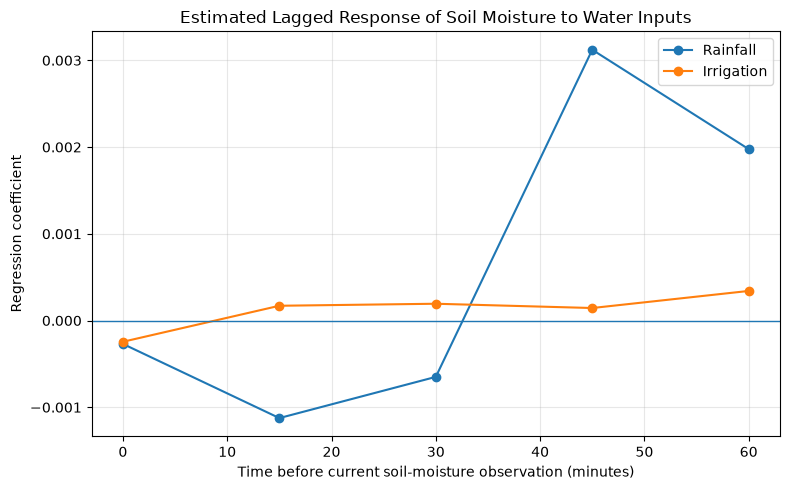

In [19]:
rain_coeffs = [
    lag_model.coef_[0],
    lag_model.coef_[1],
    lag_model.coef_[2],
    lag_model.coef_[3],
    lag_model.coef_[4]
]

irrigation_coeffs = [
    lag_model.coef_[5],
    lag_model.coef_[6],
    lag_model.coef_[7],
    lag_model.coef_[8],
    lag_model.coef_[9]
]

lag_minutes = [0, 15, 30, 45, 60]

plt.figure(figsize=(8, 5))

plt.plot(
    lag_minutes,
    rain_coeffs,
    marker="o",
    label="Rainfall"
)

plt.plot(
    lag_minutes,
    irrigation_coeffs,
    marker="o",
    label="Irrigation"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Time before current soil-moisture observation (minutes)")
plt.ylabel("Regression coefficient")
plt.title("Estimated Lagged Response of Soil Moisture to Water Inputs")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [20]:
history_results = []

for n_lags in [1, 2, 4, 8, 12]:
    
    temp_data = balance_data.copy()
    
    lag_features_test = [
        "Rainfall",
        "Irrigation",
        "Temperature"
    ]
    
    for lag in range(1, n_lags + 1):
        temp_data[f"Rainfall_lag{lag}"] = temp_data["Rainfall"].shift(lag)
        temp_data[f"Irrigation_lag{lag}"] = temp_data["Irrigation"].shift(lag)
        
        lag_features_test.extend([
            f"Rainfall_lag{lag}",
            f"Irrigation_lag{lag}"
        ])
    
    expected_time = pd.Timedelta(minutes=15 * n_lags)
    
    continuous = (
        temp_data["Timestamps"].diff(n_lags)
        == expected_time
    )
    
    temp_data = temp_data[continuous].dropna(
        subset=lag_features_test + ["Delta_theta"]
    )
    
    temp_train = temp_data[
        temp_data["Timestamps"] <= train_data["Timestamps"].max()
    ]
    
    temp_test = temp_data[
        temp_data["Timestamps"] > train_data["Timestamps"].max()
    ]
    
    model = LinearRegression()
    
    model.fit(
        temp_train[lag_features_test],
        temp_train["Delta_theta"]
    )
    
    predictions = model.predict(
        temp_test[lag_features_test]
    )
    
    history_results.append({
        "History_minutes": n_lags * 15,
        "MAE": mean_absolute_error(
            temp_test["Delta_theta"],
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                temp_test["Delta_theta"],
                predictions
            )
        ),
        "R2": r2_score(
            temp_test["Delta_theta"],
            predictions
        )
    })

history_results = pd.DataFrame(history_results)

history_results

,History_minutes,MAE,RMSE,R2
0,15,0.000144,0.000565,0.015123
1,30,0.000139,0.000545,0.093773
2,60,0.000181,0.000562,0.053773
3,120,0.000167,0.000449,-0.765368
4,180,0.000157,0.000446,-0.889697


In [21]:
history_counts = []

for n_lags in [1, 2, 4, 8, 12]:

    temp_data = balance_data.copy()

    for lag in range(1, n_lags + 1):
        temp_data[f"time_lag_{lag}"] = (
            temp_data["Timestamps"].shift(lag)
        )

    continuous = pd.Series(
        True,
        index=temp_data.index
    )

    for lag in range(1, n_lags + 1):

        expected_difference = pd.Timedelta(
            minutes=15 * lag
        )

        continuous &= (
            temp_data["Timestamps"]
            - temp_data[f"time_lag_{lag}"]
            == expected_difference
        )

    valid = temp_data[continuous].copy()

    valid_train = valid[
        valid["Timestamps"]
        <= train_data["Timestamps"].max()
    ]

    valid_test = valid[
        valid["Timestamps"]
        > train_data["Timestamps"].max()
    ]

    history_counts.append({
        "History_minutes": n_lags * 15,
        "Training_rows": len(valid_train),
        "Testing_rows": len(valid_test)
    })

pd.DataFrame(history_counts)

,History_minutes,Training_rows,Testing_rows
0,15,8832,2168
1,30,8828,2131
2,60,8824,2072
3,120,8816,2000
4,180,8808,1945


In [22]:
max_lag = 12  # 12 × 15 minutes = 180 minutes

common_data = balance_data.copy()

for lag in range(1, max_lag + 1):
    common_data[f"time_lag_{lag}"] = (
        common_data["Timestamps"].shift(lag)
    )

continuous_180 = pd.Series(
    True,
    index=common_data.index
)

for lag in range(1, max_lag + 1):

    expected_difference = pd.Timedelta(
        minutes=15 * lag
    )

    continuous_180 &= (
        common_data["Timestamps"]
        - common_data[f"time_lag_{lag}"]
        == expected_difference
    )

common_data = common_data[
    continuous_180
].copy()

common_train = common_data[
    common_data["Timestamps"]
    <= train_data["Timestamps"].max()
]

common_test = common_data[
    common_data["Timestamps"]
    > train_data["Timestamps"].max()
]

print("Common training observations:", len(common_train))
print("Common testing observations:", len(common_test))

print("\nTest period:")
print(
    common_test["Timestamps"].min(),
    "to",
    common_test["Timestamps"].max()
)

Common training observations: 8808
Common testing observations: 1945

Test period:
2022-11-01 00:45:00 to 2023-02-28 23:45:00


In [23]:
fair_results = []

for n_lags in [1, 2, 4, 8, 12]:

    temp_data = balance_data.copy()

    features = [
        "Rainfall",
        "Irrigation",
        "Temperature"
    ]

    for lag in range(1, n_lags + 1):

        temp_data[f"Rainfall_lag{lag}"] = (
            temp_data["Rainfall"].shift(lag)
        )

        temp_data[f"Irrigation_lag{lag}"] = (
            temp_data["Irrigation"].shift(lag)
        )

        features.extend([
            f"Rainfall_lag{lag}",
            f"Irrigation_lag{lag}"
        ])

    # Use exactly the timestamps from the common datasets
    temp_train = temp_data[
        temp_data["Timestamps"].isin(
            common_train["Timestamps"]
        )
    ].dropna(subset=features + ["Delta_theta"])

    temp_test = temp_data[
        temp_data["Timestamps"].isin(
            common_test["Timestamps"]
        )
    ].dropna(subset=features + ["Delta_theta"])

    model = LinearRegression()

    model.fit(
        temp_train[features],
        temp_train["Delta_theta"]
    )

    predictions = model.predict(
        temp_test[features]
    )

    fair_results.append({
        "History_minutes": n_lags * 15,
        "Train_rows": len(temp_train),
        "Test_rows": len(temp_test),
        "MAE": mean_absolute_error(
            temp_test["Delta_theta"],
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                temp_test["Delta_theta"],
                predictions
            )
        ),
        "R2": r2_score(
            temp_test["Delta_theta"],
            predictions
        )
    })

fair_results = pd.DataFrame(fair_results)

fair_results

,History_minutes,Train_rows,Test_rows,MAE,RMSE,R2
0,15,8809,1945,0.000124,0.000326,-0.010657
1,30,8809,1945,0.000120,0.000337,-0.079455
2,60,8809,1945,0.000169,0.000446,-0.891686
3,120,8809,1945,0.000166,0.000447,-0.895494
4,180,8809,1945,0.000157,0.000446,-0.889690


In [24]:
persistence_test = test_data.copy()

persistence_test["Observed_next"] = (
    persistence_test["Port1"]
    + persistence_test["Delta_theta"]
)

persistence_test["Persistence_prediction"] = (
    persistence_test["Port1"]
)

persistence_mae = mean_absolute_error(
    persistence_test["Observed_next"],
    persistence_test["Persistence_prediction"]
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        persistence_test["Observed_next"],
        persistence_test["Persistence_prediction"]
    )
)

persistence_r2 = r2_score(
    persistence_test["Observed_next"],
    persistence_test["Persistence_prediction"]
)

print("PERSISTENCE BASELINE")
print("MAE:", persistence_mae)
print("RMSE:", persistence_rmse)
print("R²:", persistence_r2)

PERSISTENCE BASELINE
MAE: 0.00011362607514712545
RMSE: 0.0005791769186730302
R²: 0.9986608889010948


In [25]:
changing_test = persistence_test[
    persistence_test["Delta_theta"].abs() >= 0.001
].copy()

print("Total test observations:", len(persistence_test))
print("Changing observations:", len(changing_test))
print(
    "Percentage changing:",
    100 * len(changing_test) / len(persistence_test)
)

changing_mae = mean_absolute_error(
    changing_test["Observed_next"],
    changing_test["Persistence_prediction"]
)

changing_rmse = np.sqrt(
    mean_squared_error(
        changing_test["Observed_next"],
        changing_test["Persistence_prediction"]
    )
)

changing_r2 = r2_score(
    changing_test["Observed_next"],
    changing_test["Persistence_prediction"]
)

print("\nPERSISTENCE DURING CHANGING CONDITIONS")
print("MAE:", changing_mae)
print("RMSE:", changing_rmse)
print("R²:", changing_r2)

Total test observations: 2209
Changing observations: 196
Percentage changing: 8.872793119058397

PERSISTENCE DURING CHANGING CONDITIONS
MAE: 0.0012806122448979598
RMSE: 0.0019443796555451726
R²: 0.9884458335000661


In [26]:
wetting_test = persistence_test[
    persistence_test["Delta_theta"] >= 0.001
].copy()

drying_test = persistence_test[
    persistence_test["Delta_theta"] <= -0.001
].copy()

print("Wetting events:", len(wetting_test))
print("Drying events:", len(drying_test))

print("\nWETTING")
print(
    "MAE:",
    mean_absolute_error(
        wetting_test["Observed_next"],
        wetting_test["Persistence_prediction"]
    )
)
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            wetting_test["Observed_next"],
            wetting_test["Persistence_prediction"]
        )
    )
)

print("\nDRYING")
print(
    "MAE:",
    mean_absolute_error(
        drying_test["Observed_next"],
        drying_test["Persistence_prediction"]
    )
)
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            drying_test["Observed_next"],
            drying_test["Persistence_prediction"]
        )
    )
)

Wetting events: 93
Drying events: 103

WETTING
MAE: 0.00156989247311828
RMSE: 0.0026068561380964608

DRYING
MAE: 0.0010194174757281562
RMSE: 0.0010287139676238813


In [27]:
wetting_causes = wetting_test.copy()

wetting_causes["Condition"] = "No recorded water input"

wetting_causes.loc[
    (wetting_causes["Rainfall"] > 0) &
    (wetting_causes["Irrigation"] == 0),
    "Condition"
] = "Rainfall only"

wetting_causes.loc[
    (wetting_causes["Rainfall"] == 0) &
    (wetting_causes["Irrigation"] > 0),
    "Condition"
] = "Irrigation only"

wetting_causes.loc[
    (wetting_causes["Rainfall"] > 0) &
    (wetting_causes["Irrigation"] > 0),
    "Condition"
] = "Rainfall + irrigation"

wetting_summary = (
    wetting_causes["Condition"]
    .value_counts()
    .to_frame("Count")
)

wetting_summary["Percentage"] = (
    100 * wetting_summary["Count"] / len(wetting_causes)
)

wetting_summary

,Count,Percentage
Condition,,
No recorded water input,88,94.623656
Rainfall only,5,5.376344


In [28]:
wetting_history = wetting_test.copy()

for lag in range(1, 5):
    wetting_history[f"Rainfall_lag{lag}"] = (
        model_data.set_index("Timestamps")["Rainfall"]
        .reindex(
            wetting_history["Timestamps"]
            - pd.Timedelta(minutes=15 * lag)
        )
        .to_numpy()
    )

    wetting_history[f"Irrigation_lag{lag}"] = (
        model_data.set_index("Timestamps")["Irrigation"]
        .reindex(
            wetting_history["Timestamps"]
            - pd.Timedelta(minutes=15 * lag)
        )
        .to_numpy()
    )

for lag in range(1, 5):

    rain_count = (
        wetting_history[f"Rainfall_lag{lag}"] > 0
    ).sum()

    irrigation_count = (
        wetting_history[f"Irrigation_lag{lag}"] > 0
    ).sum()

    print(
        f"{lag * 15} minutes earlier:",
        f"Rainfall = {rain_count},",
        f"Irrigation = {irrigation_count}"
    )

ValueError: cannot reindex on an axis with duplicate labels

In [29]:
duplicate_times = model_data[
    model_data["Timestamps"].duplicated(keep=False)
].sort_values("Timestamps")

print("Rows with duplicated timestamps:", len(duplicate_times))
print(
    "Unique duplicated timestamps:",
    duplicate_times["Timestamps"].nunique()
)

duplicate_times[
    [
        "Timestamps",
        "Port1",
        "Rainfall",
        "Irrigation",
        "Temperature"
    ]
].head(20)

Rows with duplicated timestamps: 8
Unique duplicated timestamps: 4


,Timestamps,Port1,Rainfall,Irrigation,Temperature
8657,2022-10-30 04:30:00,0.233,0.0,0.0,17.4
8661,2022-10-30 04:30:00,0.233,0.0,0.0,17.4
8658,2022-10-30 04:45:00,0.233,0.0,0.0,17.4
8662,2022-10-30 04:45:00,0.233,0.0,0.0,17.4
8659,2022-10-30 05:00:00,0.233,0.0,0.0,17.4
8663,2022-10-30 05:00:00,0.233,0.0,0.0,17.4
8660,2022-10-30 05:15:00,0.233,0.0,0.0,17.4
8664,2022-10-30 05:15:00,0.233,0.0,0.0,17.4


In [30]:
lookup_data = (
    model_data
    .sort_values("Timestamps")
    .drop_duplicates(
        subset="Timestamps",
        keep="first"
    )
    .copy()
)

print("Original rows:", len(model_data))
print("Lookup rows:", len(lookup_data))

print(
    "Duplicate timestamps remaining:",
    lookup_data["Timestamps"].duplicated().sum()
)

Original rows: 11770
Lookup rows: 11766
Duplicate timestamps remaining: 0


In [31]:
wetting_history = wetting_test.copy()

lookup_indexed = lookup_data.set_index("Timestamps")

for lag in range(1, 5):

    previous_times = (
        wetting_history["Timestamps"]
        - pd.Timedelta(minutes=15 * lag)
    )

    wetting_history[f"Rainfall_lag{lag}"] = (
        lookup_indexed["Rainfall"]
        .reindex(previous_times)
        .to_numpy()
    )

    wetting_history[f"Irrigation_lag{lag}"] = (
        lookup_indexed["Irrigation"]
        .reindex(previous_times)
        .to_numpy()
    )

for lag in range(1, 5):

    rain_count = (
        wetting_history[f"Rainfall_lag{lag}"] > 0
    ).sum()

    irrigation_count = (
        wetting_history[f"Irrigation_lag{lag}"] > 0
    ).sum()

    print(
        f"{lag * 15} minutes earlier:",
        f"Rainfall = {rain_count},",
        f"Irrigation = {irrigation_count}"
    )

15 minutes earlier: Rainfall = 7, Irrigation = 0
30 minutes earlier: Rainfall = 9, Irrigation = 0
45 minutes earlier: Rainfall = 8, Irrigation = 0
60 minutes earlier: Rainfall = 10, Irrigation = 0


In [32]:
rain_lag_columns = [
    "Rainfall_lag1",
    "Rainfall_lag2",
    "Rainfall_lag3",
    "Rainfall_lag4"
]

irrigation_lag_columns = [
    "Irrigation_lag1",
    "Irrigation_lag2",
    "Irrigation_lag3",
    "Irrigation_lag4"
]

wetting_history["Recent_rainfall"] = (
    wetting_history[rain_lag_columns]
    .gt(0)
    .any(axis=1)
)

wetting_history["Recent_irrigation"] = (
    wetting_history[irrigation_lag_columns]
    .gt(0)
    .any(axis=1)
)

recent_rain_count = wetting_history["Recent_rainfall"].sum()
recent_irrigation_count = wetting_history["Recent_irrigation"].sum()

print("Total wetting events:", len(wetting_history))

print(
    "Wetting events with rainfall in previous 60 min:",
    recent_rain_count
)

print(
    "Percentage:",
    100 * recent_rain_count / len(wetting_history)
)

print(
    "\nWetting events with irrigation in previous 60 min:",
    recent_irrigation_count
)

print(
    "Percentage:",
    100 * recent_irrigation_count / len(wetting_history)
)

Total wetting events: 93
Wetting events with rainfall in previous 60 min: 13
Percentage: 13.978494623655914

Wetting events with irrigation in previous 60 min: 0
Percentage: 0.0


## Initial physics-model findings

The exploratory water-balance analysis showed that soil moisture generally increased during intervals with recorded water input and decreased slightly when no water input was recorded. Temperature also showed a clear relationship with drying, with larger average moisture losses occurring during warmer conditions.

A simple linear water-balance approximation using rainfall, irrigation and temperature was not sufficient to explain short-term soil-moisture changes on unseen data. Adding historical rainfall and irrigation measurements showed that temporal information matters, but longer linear lag windows did not consistently improve prediction.

A persistence model performed very well for the overall 15-minute soil-moisture level because most observations changed very little between consecutive measurements. However, its errors increased substantially during meaningful wetting and drying transitions, particularly during wetting events.

Of the 93 larger wetting transitions in the test period, 13 were preceded by recorded rainfall within the previous 60 minutes. No positive irrigation measurement was found in the preceding 60 minutes for these events. This does not show that irrigation had no effect because the irrigation record contains missing observations and soil-water response may occur over longer or spatially different time scales.

These results suggest that short-term soil-moisture behaviour cannot be represented adequately by an instantaneous linear water-balance equation alone. The physics model therefore provides a useful baseline and physical structure for the next stage, where nonlinear time-series learning will be investigated.